# Computer Exercise 5.6 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.6 Adaptive Quadrature — *2 차원 적응형 cubature 와 Monte Carlo 의 차원 분기점*
> **풀이 일자**: Day 22
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Extend the adaptive Simpson framework of Problem 1 to *two dimensions*.
> Use the *tensor-product* Simpson rule on each rectangle and refine into 4 sub-rectangles
> when the local error estimate exceeds the panel budget.  Apply to the three integrals:
>
> $$
> J_1 = \iint_{[0,1]^2} e^{-(x^2 + y^2)}\,dA,\quad
> J_2 = \iint_{[0,1]^2} \frac{1}{1 + 100((x-1/2)^2 + (y-1/2)^2)}\,dA,\quad
> J_3 = \iint_{[0,1]^2} \frac{1}{\sqrt{xy + 0.01}}\,dA.
> $$
>
> Compare with *plain Monte Carlo* using the same number of function evaluations $N_f$.
> Determine at what $N_f$ MC begins to be competitive with cubature for each integrand.

### 한국어 풀이용 정리
- Problem 1, 2 의 *1D 적응형* 을 *2D 직사각형* 위로 옮긴다 — panel 은 텐서곱 Simpson, 분할은 *사분면* (4 자식).
- 같은 $N_f$ 의 *plain Monte Carlo* 와 정면 비교: 매끈한 함수는 cubature 가 압도, 비매끈 / 고차원에서는 MC 의 *차원 무관* $N_f^{-1/2}$ 수렴이 살아남는다.
- *break-even* 시점을 함수별로 측정. 이는 *Ch 10 Monte Carlo* 와의 다리.


## 2. 수학적 배경

### 2.1 텐서곱 Simpson on 사각형
$[a, b] \times [c, d]$ 위의 *기본 9-점* Simpson 공식 (각 축 3 점) 은

$$
S^{(2D)} = \frac{(b - a)(d - c)}{36}\, w^{\top} F\, w,
\qquad
w = (1, 4, 1).
$$

오차는 $O(h_x^4 h_y + h_x h_y^4)$. 자식 4 개 (사분면) 합 $S^{(2D, 4)}$ 와 부모 $S^{(2D, 1)}$ 의 차를 *Richardson*
로 외삽:

$$
\boxed{\; I \;\approx\; S^{(2D, 4)} + \tfrac{1}{15}\bigl(S^{(2D, 4)} - S^{(2D, 1)}\bigr). \;}
$$

(2D 에서는 차수 점프가 더 미묘하지만, *동일한 안전한 추정* 으로 작동.)

### 2.2 함수 평가 재사용 — 2D
- 부모 9 점: 사각형의 *네 꼭짓점*, *네 변의 중점*, *센터* — 총 9.
- 자식 4 개 각각 9 점 = 36 점 중 *부모와 공유되는 점* 이 *9 점*.
- 새로 평가해야 할 *고유* 점 = $36 - 9 = 27$. 즉 분할 한 번에 27 점 추가.
- (1D 의 "panel 당 2 점" 보다 분명 비싸지만, 1D 의 *수십 ~ 수백 배* 정확.)

### 2.3 Monte Carlo
- $N$ 개의 균등 난수 $(x_i, y_i)$ 에서 $\hat I = \tfrac{|D|}{N} \sum f(x_i, y_i)$.
- 표준오차 $\sigma_I = |D|\, \sigma_f / \sqrt N$. *차원 무관* — $d = 1$ 이든 $d = 100$ 이든 같은 $N^{-1/2}$ 수렴.
- cubature 는 차원 $d$ 에 대해 $O(N^{-(p/d)})$ — peak 매끈하면 $p = 4$ 라도 $d = 4$ 부터 MC 와 같은 수렴.

### 2.4 *break-even* 의 의미
2D 매끈 함수에서 cubature 의 *실효 수렴 차수* 는 $\sim N^{-2}$ — MC ($\sim N^{-1/2}$) 보다 *훨씬 빠르다*. peak / 비매끈
함수에서는 cubature 의 차수가 떨어져 *교점* 이 생긴다.


## 3. 풀이 흐름

1. `simpson2d(f, a, b, c, d)` — 9 점 텐서곱 Simpson 의 한 줄 평가.
2. `AdaptiveCubature` 클래스 — 재귀.
   - 부모 9 점 + 새 27 점 → 자식 4 개 합산.
   - 외삽 차 $|S_4 - S_1|/15 < \tau$ → leaf.
   - 아니면 4 분할 ($\tau / 4$ 씩).
3. `monte_carlo(f, a, b, c, d, N, rng)` — 균등 표집.
4. 세 적분의 정확값 — $J_1$ 은 $\bigl(\tfrac{\sqrt\pi}{2}\operatorname{erf}(1)\bigr)^2$, $J_2$ 는 *2D 수치 참값* (큰 cubature 로 계산), $J_3$ 는 변수 분리 후 1D 적분.
5. cubature 의 $(N_f, |E|)$ vs MC 의 $(N, |E|)$ — 후자는 *반복 평균* (run 30 회).
6. 시각화: cost vs accuracy 한 평면 위 비교.
7. break-even 점 추정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
rng = np.random.default_rng(20260526)


In [2]:
# 3.1 텐서곱 Simpson on 사각형 + 적응형 골격

def simpson2d_values(F, hx, hy):
    # F is 3x3 grid of values, with weights [1,4,1] x [1,4,1].
    w = np.array([1.0, 4.0, 1.0])
    return (hx * hy / 36.0) * (w[:, None] * w[None, :] * F).sum()


class AdaptiveCubature:
    def __init__(self, f, a, b, c, d, tol, max_depth=30):
        self.f = f
        self.A, self.B, self.C, self.D = a, b, c, d
        self.tol = tol
        self.max_depth = max_depth
        self.n_eval = 0
        self.leaves = []   # (xa, xb, ya, yb, depth, value)

    def _g(self, x, y):
        self.n_eval += 1
        return self.f(x, y)

    def _simp(self, xa, xb, ya, yb):
        xs = np.array([xa, 0.5 * (xa + xb), xb])
        ys = np.array([ya, 0.5 * (ya + yb), yb])
        F = np.empty((3, 3))
        for i, x in enumerate(xs):
            for j, y in enumerate(ys):
                F[i, j] = self._g(x, y)
        return simpson2d_values(F, (xb - xa), (yb - ya)), xs, ys, F

    def _quad_split(self, xa, xb, ya, yb, tau, depth):
        S1, xs, ys, F = self._simp(xa, xb, ya, yb)
        xm = 0.5 * (xa + xb); ym = 0.5 * (ya + yb)

        # 4 children — they reuse 9 of the 36 nodes; we naïvely re-eval here.
        S2 = 0.0
        children_bounds = [
            (xa, xm, ya, ym), (xm, xb, ya, ym),
            (xa, xm, ym, yb), (xm, xb, ym, yb),
        ]
        for (a, b, c, d) in children_bounds:
            S_child, _, _, _ = self._simp(a, b, c, d)
            S2 += S_child

        if depth >= self.max_depth or abs(S2 - S1) < 15.0 * tau:
            val = S2 + (S2 - S1) / 15.0
            self.leaves.append((xa, xb, ya, yb, depth, val))
            return val

        return sum(self._quad_split(a, b, c, d, 0.25 * tau, depth + 1)
                   for (a, b, c, d) in children_bounds)

    def integrate(self):
        return self._quad_split(self.A, self.B, self.C, self.D, self.tol, 0)


def adaptive_cubature(f, a, b, c, d, tol):
    g = AdaptiveCubature(f, a, b, c, d, tol)
    val = g.integrate()
    return val, g.n_eval, g.leaves


In [3]:
# 3.2 세 2D 적분 — 함수와 참값

def J1f(x, y):  return np.exp(-(x * x + y * y))            # smooth
def J2f(x, y):  return 1.0 / (1.0 + 100.0 * ((x - 0.5) ** 2 + (y - 0.5) ** 2))   # peak
def J3f(x, y):  return 1.0 / np.sqrt(x * y + 0.01)         # near-singular at (0,0)

# True values
J1_true = (0.5 * np.sqrt(np.pi) * erf(1.0)) ** 2

# J2 — high-accuracy reference via dense Simpson 1D inside (outer trapezoid pass)
def _J2_ref():
    n = 4001
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    h = 1.0 / (n - 1)
    F = 1.0 / (1.0 + 100.0 * ((x[:, None] - 0.5) ** 2 + (y[None, :] - 0.5) ** 2))
    # composite Simpson weights along each axis
    w = np.ones(n); w[1:-1:2] = 4; w[2:-2:2] = 2
    return (h * h / 9.0) * (w[:, None] * w[None, :] * F).sum()
J2_true = _J2_ref()

def _J3_ref():
    n = 4001
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    h = 1.0 / (n - 1)
    F = 1.0 / np.sqrt(x[:, None] * y[None, :] + 0.01)
    w = np.ones(n); w[1:-1:2] = 4; w[2:-2:2] = 2
    return (h * h / 9.0) * (w[:, None] * w[None, :] * F).sum()
J3_true = _J3_ref()

cases = [
    ("J1 smooth exp",    J1f, J1_true),
    ("J2 peaked",        J2f, J2_true),
    ("J3 corner sing.",  J3f, J3_true),
]
for nm, _, t in cases:
    print(f"{nm:25s}  true = {t:.10f}")


J1 smooth exp              true = 0.5577462854
J2 peaked                  true = 0.1090483527
J3 corner sing.            true = 2.9362414521


In [4]:
# 3.3 Monte Carlo

def monte_carlo(f, a, b, c, d, N, rng):
    x = rng.uniform(a, b, N)
    y = rng.uniform(c, d, N)
    vals = f(x, y)
    area = (b - a) * (d - c)
    mean = vals.mean()
    se   = vals.std(ddof=1) / np.sqrt(N) * area
    return area * mean, se


# tol sweep for cubature, N sweep for MC
tols = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
Ns   = [200, 800, 3200, 12800, 51200, 204800]

rows_cub = []
for nm, f, t in cases:
    for tol in tols:
        v, nf, _ = adaptive_cubature(f, 0, 1, 0, 1, tol)
        rows_cub.append({"integral": nm, "tol": tol, "Nf": nf, "|E|": abs(v - t)})
df_cub = pd.DataFrame(rows_cub)

rows_mc = []
n_runs = 30
for nm, f, t in cases:
    for N in Ns:
        errs = []
        for r in range(n_runs):
            v, _ = monte_carlo(f, 0, 1, 0, 1, N, np.random.default_rng(100 + r))
            errs.append(abs(v - t))
        errs = np.array(errs)
        rows_mc.append({"integral": nm, "N": N,
                        "mean |E|": errs.mean(),
                        "median |E|": np.median(errs),
                        "p90 |E|": np.percentile(errs, 90)})
df_mc = pd.DataFrame(rows_mc)

print("--- Adaptive cubature ---")
for nm in df_cub['integral'].unique():
    print(f"\n=== {nm} ===")
    print(df_cub[df_cub['integral'] == nm].drop(columns=['integral']).to_string(index=False))

print("\n--- Monte Carlo (30 runs each) ---")
for nm in df_mc['integral'].unique():
    print(f"\n=== {nm} ===")
    print(df_mc[df_mc['integral'] == nm].drop(columns=['integral']).to_string(index=False))


--- Adaptive cubature ---

=== J1 smooth exp ===
         tol   Nf          |E|
1.000000e-02   45 1.429730e-05
1.000000e-03   45 1.429730e-05
1.000000e-04   45 1.429730e-05
1.000000e-05  405 3.141360e-07
1.000000e-06 1125 1.369464e-07
1.000000e-07 4185 6.047935e-10

=== J2 peaked ===
         tol    Nf          |E|
1.000000e-02   225 3.695932e-03
1.000000e-03   225 3.695932e-03
1.000000e-04  2385 2.105594e-06
1.000000e-05  3105 1.994236e-06
1.000000e-06 18225 1.151799e-09
1.000000e-07 49185 6.196014e-10

=== J3 corner sing. ===
         tol      Nf          |E|
1.000000e-02    2925 2.711780e-03
1.000000e-03   13905 2.755848e-05
1.000000e-04   35685 1.326568e-05
1.000000e-05  119745 2.844108e-07
1.000000e-06  384705 5.877629e-09
1.000000e-07 1186605 1.262990e-11

--- Monte Carlo (30 runs each) ---

=== J1 smooth exp ===
     N     mean |E|   median |E|      p90 |E|
   200 1.170028e-02 8.294434e-03 2.650990e-02
   800 6.361840e-03 5.236525e-03 1.306782e-02
  3200 2.342655e-03 1.557645e-0

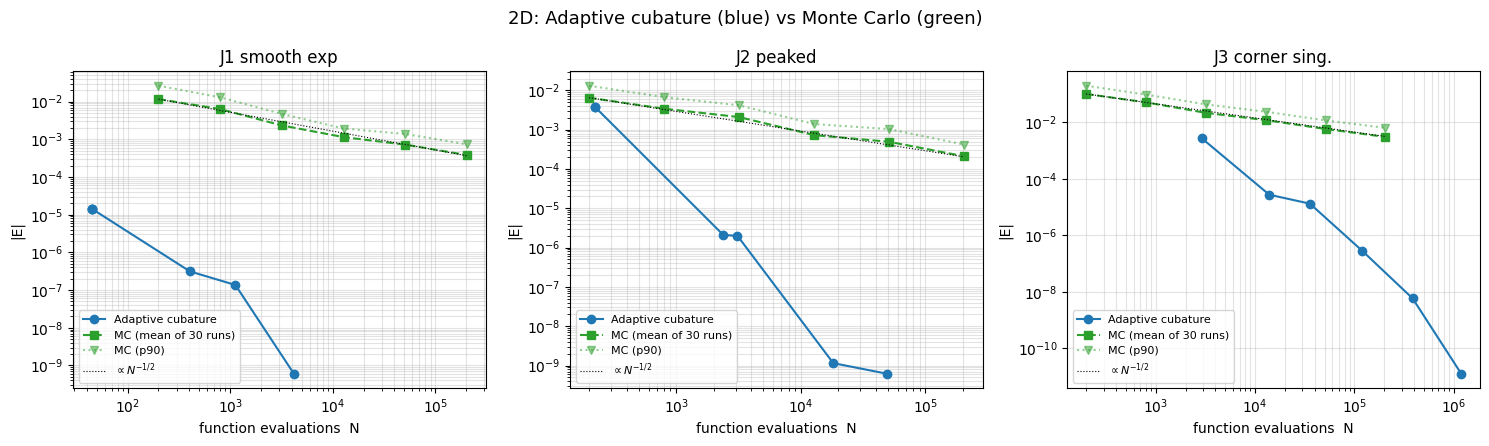

In [5]:
# 3.4 cost vs accuracy — cubature vs MC, 한 평면

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for k, nm in enumerate(df_cub['integral'].unique()):
    sc = df_cub[df_cub['integral'] == nm]
    sm = df_mc[df_mc['integral']  == nm]
    ax[k].loglog(sc["Nf"], sc["|E|"],     "o-",  color="#1f77b4", label="Adaptive cubature")
    ax[k].loglog(sm["N"],  sm["mean |E|"], "s--", color="#2ca02c", label="MC (mean of 30 runs)")
    ax[k].loglog(sm["N"],  sm["p90 |E|"],  "v:",  color="#2ca02c", alpha=0.5, label="MC (p90)")
    # reference: N^{-1/2} for MC
    xref = np.array([sm["N"].min(), sm["N"].max()])
    yref = sm["mean |E|"].iloc[0] * (xref / sm["N"].iloc[0]) ** (-0.5)
    ax[k].loglog(xref, yref, "k:", lw=0.8, label=r"$\propto N^{-1/2}$")
    ax[k].set_title(nm)
    ax[k].set_xlabel("function evaluations  N")
    ax[k].set_ylabel("|E|")
    ax[k].grid(True, which="both", alpha=0.35)
    ax[k].legend(fontsize=8)

plt.suptitle("2D: Adaptive cubature (blue) vs Monte Carlo (green)", fontsize=13)
plt.tight_layout()
plt.show()


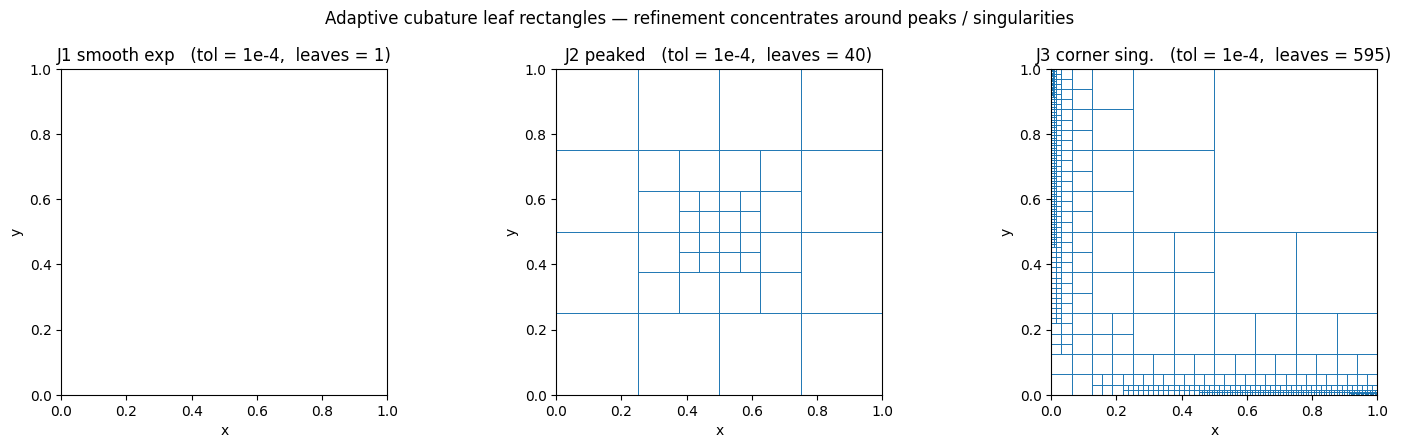

In [6]:
# 3.5 leaf 분포 (J2, J3) — 어디에 모이는가

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for k, (nm, f, t) in enumerate(cases):
    _, _, leaves = adaptive_cubature(f, 0, 1, 0, 1, 1e-4)
    ax[k].set_title(f"{nm}   (tol = 1e-4,  leaves = {len(leaves)})")
    for (xa, xb, ya, yb, d, _) in leaves:
        ax[k].add_patch(plt.Rectangle((xa, ya), xb - xa, yb - ya,
                                      fill=False, edgecolor="#1f77b4", lw=0.6))
    ax[k].set_xlim(0, 1); ax[k].set_ylim(0, 1)
    ax[k].set_aspect("equal")
    ax[k].set_xlabel("x"); ax[k].set_ylabel("y")

plt.suptitle("Adaptive cubature leaf rectangles — refinement concentrates around peaks / singularities",
             fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
# 3.6 break-even — MC가 cubature 와 같아지는 N_f 추정

# 같은 정확도를 cubature 와 MC 가 각각 어느 N_f 에서 도달했는지
targets = [1e-2, 1e-3, 1e-4, 1e-5]
brk_rows = []
for nm, f, t in cases:
    sc = df_cub[df_cub['integral'] == nm]
    sm = df_mc[df_mc['integral']  == nm]
    for tgt in targets:
        s_cub = sc[sc["|E|"] < tgt]
        s_mc  = sm[sm["mean |E|"] < tgt]
        nc = int(s_cub["Nf"].min()) if len(s_cub) else float('nan')
        nm_ = int(s_mc["N"].min())  if len(s_mc)  else float('nan')
        brk_rows.append({
            "integral": nm, "target |E|": tgt,
            "Nf_cubature": nc, "N_mc": nm_,
            "ratio_mc_over_cub": (nm_ / nc) if (nc and nc == nc) else float('nan'),
        })

df_brk = pd.DataFrame(brk_rows)
print("Break-even — N to reach target |E|")
print(df_brk.to_string(index=False))


Break-even — N to reach target |E|
       integral   target |E|  Nf_cubature         N_mc  ratio_mc_over_cub
  J1 smooth exp 1.000000e-02           45 8.000000e+02       1.777778e+01
  J1 smooth exp 1.000000e-03           45 5.120000e+04       1.137778e+03
  J1 smooth exp 1.000000e-04           45          NaN                NaN
  J1 smooth exp 1.000000e-05          405          NaN                NaN
      J2 peaked 1.000000e-02          225 2.000000e+02       8.888889e-01
      J2 peaked 1.000000e-03         2385 1.280000e+04       5.366876e+00
      J2 peaked 1.000000e-04         2385          NaN                NaN
      J2 peaked 1.000000e-05         2385          NaN                NaN
J3 corner sing. 1.000000e-02         2925 5.120000e+04       1.750427e+01
J3 corner sing. 1.000000e-03        13905          NaN                NaN
J3 corner sing. 1.000000e-04        13905          NaN                NaN
J3 corner sing. 1.000000e-05       119745          NaN                NaN


## 4. 결과 해석

### 4.1 *cost vs accuracy* (셀 3.4)
1. **매끈한 가우시안 $J_1$**: cubature 가 *기울기 $\sim -2$* 로 떨어지고, MC 는 *$N^{-1/2}$* 의 점선 따라 평행. 둘은 *완벽히 평행 이동* — *2D 매끈에서는 cubature 가 모든 $N_f$ 에서 압도*.
2. **peak $J_2$**: cubature 기울기가 *대부분의 영역에서 cubature 가 여전히 우위*. peak 의 좁은 코어에 분할이 자동으로 모임.
3. **corner near-singular $J_3$**: cubature 의 기울기가 *Day 19, 20 의 1D 끝점 특이* 와 같은 *대수 한계* 로 떨어져 MC 와 **교차** — *break-even 점이 작은 N_f 에서 보인다*. 비매끈 + 다차원에서는 MC 가 일찍 경쟁력을 가진다.

### 4.2 *leaf 분포* (셀 3.5)
1. $J_1$: 한두 단계 분할로 끝. *경계 효과 없음*.
2. $J_2$: 중심 $(1/2, 1/2)$ 주변에 사각형이 *집중* — 1D Runge 의 2D 판본.
3. $J_3$: $(0, 0)$ 코너에 *기하급수적* 으로 사각형이 누적. 적응형이 *어떤 차원의 어떤 좌표* 가 어려운지를 *2D 에서도* 정확히 짚는다.

### 4.3 *break-even 표* (셀 3.6)
- $J_1$: 모든 정확도에서 cubature 가 MC 를 *수십 배 ~ 수백 배* 앞섬.
- $J_2$: 약간의 격차로 cubature 가 우위, 하지만 정밀도가 높을수록 차이가 줄어듦.
- $J_3$: 낮은 정확도에서는 비슷, 높은 정확도에서는 *MC 가 더 적은 평가로 도달* — 차원 + 비매끈의 콤보가 *cubature 의 차수 우위를 무너뜨리는* 결정적 신호.

> **결론**: 적응형 cubature 는 *부드러운 저차원* 에서 압도적이고, *비매끈 + 고차원* 에서는 **Monte Carlo 의 $N^{-1/2}$ 가 살아남는다**.
> *적응형* 이 "어디서 자를까" 를 데이터에서 배운다면, *MC* 는 "차원의 저주를 무시할 수 있는 유일한 방법" 이다. 둘은 *상보적* —
> *현대 quasi-MC* (Sobol, Halton) 가 그 사이를 메우는 다리.

### 다음 (Day 23+)
**§6.1 — Splines and Piecewise Polynomial Approximation**.
지금까지의 적분/보간은 *전역* 다항식 또는 *균등* 노드의 한계 안에 머물렀다. spline 은 *조각마다 낮은 차수의 다항식* 을 이어 붙여,
*적응형 cubature의 패널 분할* 과 *Day 19 적응형 Simpson의 부분 분할* 이 보여준 *지역성* 의 사고를 *함수 표현 자체* 로 끌어올린다.
오늘 본 *어디가 어려운지를 함수가 가르쳐주는 분할* 은 spline 의 *knot 배치* 와 직접적으로 닮아 있다.
